# 08 — Synthèse Finale des Résultats

Consolide tous les résultats des notebooks 01-07 en tableaux et figures
prêts à intégrer directement dans la Section 7 de la thèse.


In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt

with open('../results/validation_metrics.json') as f:
    validation = json.load(f)

robustness = pd.read_csv('../results/robustness_results.csv')
fairness_age = pd.read_csv('../results/fairness_par_age.csv')
fairness_imc = pd.read_csv('../results/fairness_par_imc.csv')
comparison_AB = pd.read_csv('../results/comparaison_modeles_A_B_cameroun.csv', index_col=0)


## 8.1 Tableau récapitulatif KPIs (pour Section 7 thèse)

In [2]:
kpi_summary = pd.DataFrame({
    'KPI': ['Sensibilité', 'Spécificité', 'AUC ROC', 'Accuracy'],
    'Cible': ['≥ 85%', '≥ 75%', '≥ 0.85', 'N/A'],
    'Résultat': [
        f"{validation['modele_A_seuil_ajuste_85pct']['sensibilite']*100:.1f}%",
        f"{validation['modele_A_seuil_ajuste_85pct']['specificite']*100:.1f}%",
        f"{validation['modele_A_seuil_ajuste_85pct']['auc_roc']:.3f}",
        f"{validation['modele_A_seuil_ajuste_85pct']['accuracy']*100:.1f}%",
    ],
    'Atteint': [
        validation['modele_A_seuil_ajuste_85pct']['kpi_sensibilite_85_atteint'],
        validation['modele_A_seuil_ajuste_85pct']['kpi_specificite_75_atteint'],
        validation['modele_A_seuil_ajuste_85pct']['kpi_auc_085_atteint'],
        'N/A'
    ]
})
print(kpi_summary.to_string(index=False))


        KPI  Cible Résultat Atteint
Sensibilité  ≥ 85%    85.2%    True
Spécificité  ≥ 75%    47.2%   False
    AUC ROC ≥ 0.85    0.789   False
   Accuracy    N/A    67.5%     N/A


## 8.2 Export Excel complet pour intégration thèse

In [3]:
with pd.ExcelWriter('../results/summary_thesis.xlsx', engine='openpyxl') as writer:
    kpi_summary.to_excel(writer, sheet_name='KPIs_principaux', index=False)
    comparison_AB.to_excel(writer, sheet_name='Modele_A_vs_B')
    robustness.to_excel(writer, sheet_name='Robustesse', index=False)
    fairness_age.to_excel(writer, sheet_name='Equite_age', index=False)
    fairness_imc.to_excel(writer, sheet_name='Equite_imc', index=False)

print("✅ results/summary_thesis.xlsx généré — prêt pour rédaction Section 7")


✅ results/summary_thesis.xlsx généré — prêt pour rédaction Section 7


## 8.3 Figure de synthèse — Dashboard final résultats

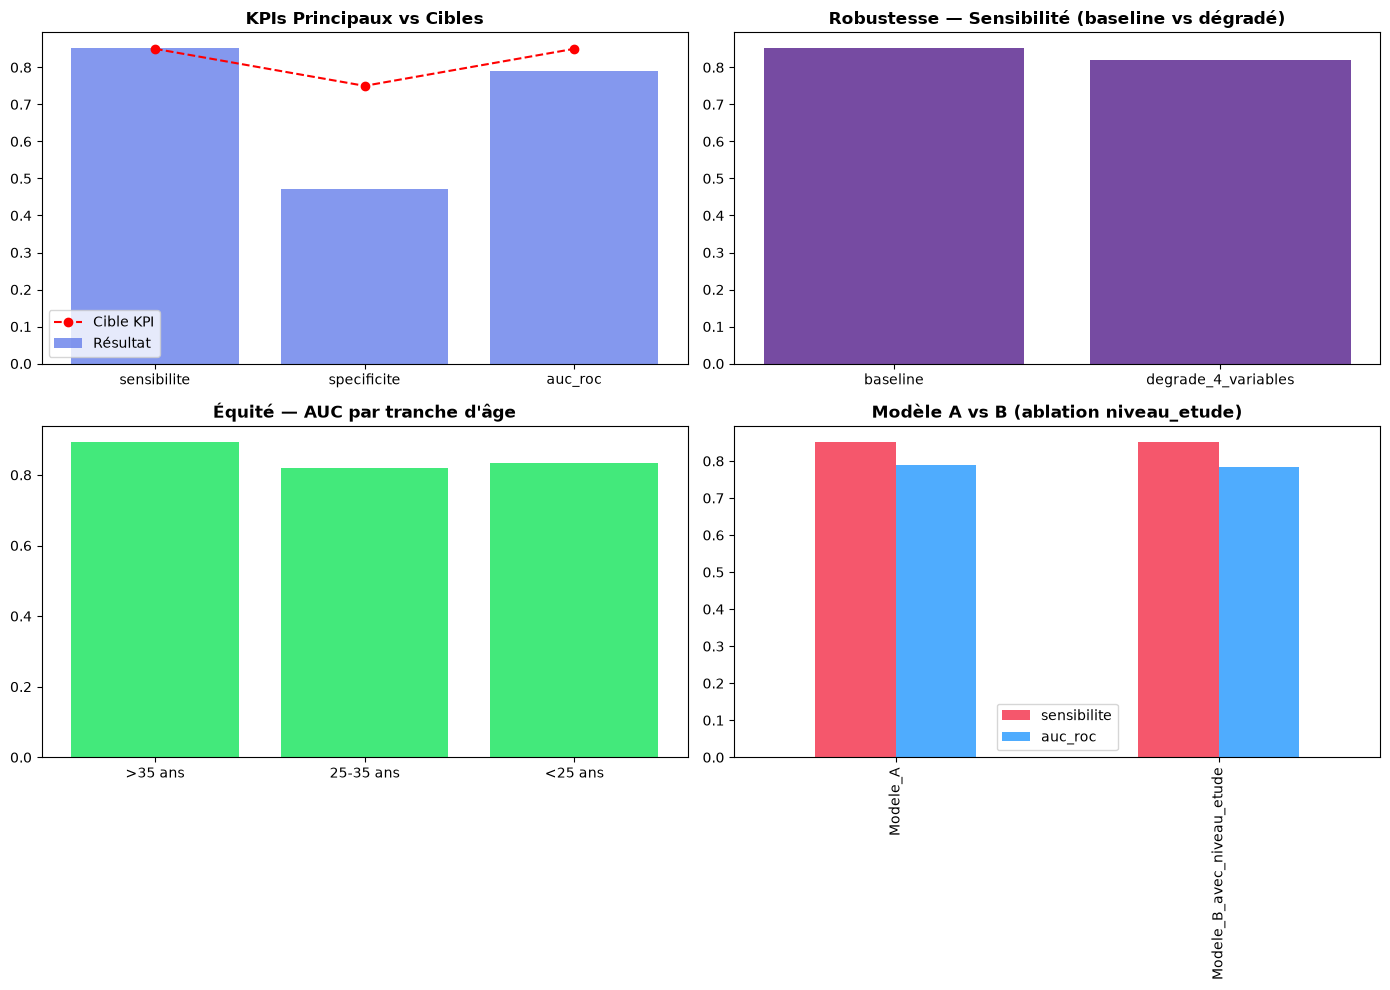

✅ Dashboard synthèse sauvegardé dans figures/08_dashboard_synthese_finale.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# KPI vs cible
kpis = ['sensibilite','specificite','auc_roc']
targets = [0.85, 0.75, 0.85]
values = [validation['modele_A_seuil_ajuste_85pct'][k] for k in kpis]
axes[0,0].bar(kpis, values, color='#667eea', alpha=0.8, label='Résultat')
axes[0,0].plot(kpis, targets, 'ro--', label='Cible KPI')
axes[0,0].set_title('KPIs Principaux vs Cibles', fontweight='bold')
axes[0,0].legend()

# Robustesse
axes[0,1].bar(robustness['scenario'], robustness['sensibilite'], color='#764ba2')
axes[0,1].set_title('Robustesse — Sensibilité (baseline vs dégradé)', fontweight='bold')

# Équité âge
axes[1,0].bar(fairness_age['groupe'], fairness_age['auc_roc'], color='#43e97b')
axes[1,0].set_title('Équité — AUC par tranche d\'âge', fontweight='bold')

# Comparaison A vs B
comparison_AB[['sensibilite','auc_roc']].plot(kind='bar', ax=axes[1,1], color=['#f5576c','#4facfe'])
axes[1,1].set_title('Modèle A vs B (ablation niveau_etude)', fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/08_dashboard_synthese_finale.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Dashboard synthèse sauvegardé dans figures/08_dashboard_synthese_finale.png")


## 8.4 Conclusion — Prêt pour rédaction Section 7 de la thèse

Tous les résultats numériques nécessaires sont maintenant disponibles dans :
- `results/summary_thesis.xlsx` — tableaux consolidés
- `figures/*.png` — toutes les figures (EDA, ROC, confusion matrix, SHAP, équité, dashboard)
- `results/*.json` et `*.csv` — données brutes pour vérification

**Prochaine étape :** revenir en conversation avec Claude, présenter ces résultats,
et rédiger la Section 7 de la thèse avec des chiffres authentiques.
